In [1]:
from dynrdpg import DynamicRDPG
from dynrdpg.datasets import simulate_network_gp

## Matern ($\nu = 2.5$) 

In [2]:
k_steps = 5
nu = 2.5

Y, X, probas_true = simulate_network_gp(
        n_nodes=200, n_time_steps=50 + k_steps,
        density=0.2, gp_type='matern', nu=nu,
        length_scale=3, random_state=123)
subdiag = np.tril_indices(Y[0].shape[0], k=-1)

In [3]:
rdpg_rw1 = DynamicRDPG(n_features=2, rw_order=1, random_state=42)
rdpg_rw1.sample(Y[:-k_steps], n_burnin=2500, n_samples=2500)

In [4]:
rdpg_rw2 = DynamicRDPG(n_features=2, rw_order=2, random_state=42)
rdpg_rw2.sample(Y[:-k_steps], n_burnin=2500, n_samples=2500)

In [5]:
from graspologic.embed import AdjacencySpectralEmbed as ASE
import scipy.sparse as sp
from scipy.linalg import orthogonal_procrustes

X_ase = []
for t in range(len(Y[:-k_steps])):
    X_ase.append(ASE(n_components=2).fit_transform(sp.csr_array(Y[t])))
X_ase = np.stack(X_ase)

for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_ase[t], X[t])
    X_ase[t] = X_ase[t] @ R

/Users/joshua/.pyenv/versions/stats/lib/python3.10/site-packages/graspologic/embed/base.py:199: UserWarning: Input graph is not fully connected. Results may notbe optimal. You can compute the largest connected component byusing ``graspologic.utils.largest_connected_component``.
  warnings.warn(msg, UserWarning)


In [6]:
from graspologic.embed import OmnibusEmbed as OMNI

X_omni = OMNI(n_components=2).fit_transform(Y[:-k_steps])
for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_omni[t], X[t])
    X_omni[t] = X_omni[t] @ R

In [7]:
from scipy.linalg import orthogonal_procrustes

X_est_rw1 = rdpg_rw1.samples_['X'].copy()
for t in range(len(Y)-k_steps):
    for i in range(X_est_rw1.shape[0]):
        R, _ = orthogonal_procrustes(X_est_rw1[i, t], X[t])
        X_est_rw1[i, t] = X_est_rw1[i, t] @ R

In [8]:
from scipy.linalg import orthogonal_procrustes

X_est_rw2 = rdpg_rw2.samples_['X'].copy()
for t in range(len(Y)-k_steps):
    for i in range(X_est_rw2.shape[0]):
        R, _ = orthogonal_procrustes(X_est_rw2[i, t], X[t])
        X_est_rw2[i, t] = X_est_rw2[i, t] @ R

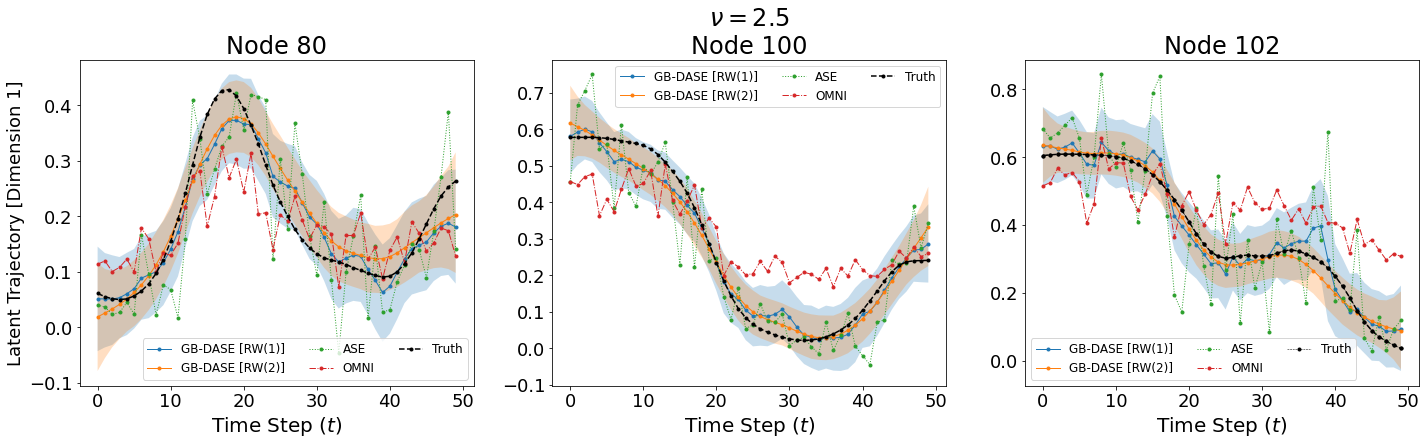

In [9]:
fig, ax = plt.subplots(figsize=(24, 6), ncols=3)

h = 1
idx = 80
X_est_h_rw1 = X_est_rw1[..., idx, h]
ci = np.quantile(X_est_h_rw1, q=[0.025, 0.975], axis=0)
ax[0].plot(X_est_h_rw1.mean(axis=0), marker='.', linestyle='-', lw=1, label='GB-DASE [RW(1)]')
ax[0].fill_between(np.arange(len(Y) - k_steps), ci[0,:], ci[1, :], alpha=0.25)


X_est_h_rw2 = X_est_rw2[..., idx, h]
ci = np.quantile(X_est_h_rw2, q=[0.025, 0.975], axis=0)
ax[0].plot(X_est_h_rw2.mean(axis=0), marker='.', linestyle='-', lw=1, label='GB-DASE [RW(2)]')
ax[0].fill_between(np.arange(len(Y) - k_steps), ci[0,:], ci[1, :], alpha=0.25)

ax[0].plot(X_ase[:, idx, h], '.:', lw=1, label = 'ASE')
ax[0].plot(X_omni[:, idx, h], '.-.', lw=1, label = 'OMNI')
ax[0].plot(X[:-k_steps, idx, h], 'k.--', label = 'Truth')

#ax[0].set_ylabel(r'$\nu = 2.5$' + '\n'+ r'Latent Trajectory [Dimension 1]', fontsize=18)
ax[0].set_ylabel(r'Latent Trajectory [Dimension 1]', fontsize=18)
ax[0].set_xlabel(r'Time Step ($t$)', fontsize=20)
ax[0].legend(ncols=3, fontsize=12)
ax[0].set_title(f'Node {idx}', fontsize=24)
ax[0].tick_params(axis='both', which='major', labelsize=18)

idx = 100
X_est_h_rw1 = X_est_rw1[..., idx, h]
ci = np.quantile(X_est_h_rw1, q=[0.025, 0.975], axis=0)
ax[1].plot(X_est_h_rw1.mean(axis=0), marker='.', linestyle='-', lw=1, label='GB-DASE [RW(1)]')
ax[1].fill_between(np.arange(len(Y) - k_steps), ci[0,:], ci[1, :], alpha=0.25)

X_est_h_rw2 = X_est_rw2[..., idx, h]
ci = np.quantile(X_est_h_rw2, q=[0.025, 0.975], axis=0)
ax[1].plot(X_est_h_rw2.mean(axis=0), marker='.', linestyle='-', lw=1, label='GB-DASE [RW(2)]')
ax[1].fill_between(np.arange(len(Y) - k_steps), ci[0,:], ci[1, :], alpha=0.25)

ax[1].plot(X_ase[:, idx, h], '.:', lw=1, label='ASE')
ax[1].plot(X_omni[:, idx, h], '.-.', lw=1, label='OMNI')
ax[1].plot(X[:-k_steps, idx, h], 'k.--', label='Truth')

ax[1].set_xlabel(r'Time Step ($t$)', fontsize=20)
ax[1].legend(ncols=3, fontsize=12)
ax[1].set_title(r'$\nu = 2.5$' + f'\nNode {idx}', fontsize=24)
ax[1].tick_params(axis='both', which='major', labelsize=18)

idx = 102
X_est_h_rw1 = X_est_rw1[..., idx, h]
ci = np.quantile(X_est_h_rw1, q=[0.025, 0.975], axis=0)
ax[2].plot(X_est_h_rw1.mean(axis=0), marker='.', linestyle='-', lw=1, label='GB-DASE [RW(1)]')
ax[2].fill_between(np.arange(len(Y) - k_steps), ci[0,:], ci[1, :], alpha=0.25)

X_est_h_rw2 = X_est_rw2[..., idx, h]
ci = np.quantile(X_est_h_rw2, q=[0.025, 0.975], axis=0)
ax[2].plot(X_est_h_rw2.mean(axis=0), marker='.', linestyle='-', lw=1, label='GB-DASE [RW(2)]')
ax[2].fill_between(np.arange(len(Y) - k_steps), ci[0,:], ci[1, :], alpha=0.25)
ax[2].plot(X[:-k_steps, idx, h], 'k.--')

ax[2].plot(X_ase[:, idx, h], '.:', lw=1, label='ASE')
ax[2].plot(X_omni[:, idx, h], '.-.', lw=1, label='OMNI')
ax[2].plot(X[:-k_steps, idx, h], 'k.--', lw=0.5, label='Truth')

ax[2].set_xlabel(r'Time Step ($t$)', fontsize=20)
ax[2].legend(ncols=3, fontsize=12)
ax[2].set_title(f'Node {idx}', fontsize=24)
ax[2].tick_params(axis='both', which='major', labelsize=18)

## Matern ($\nu = 0.5$) 

In [10]:
k_steps = 5
nu = 0.5

Y, X, probas_true = simulate_network_gp(
        n_nodes=200, n_time_steps=50 + k_steps,
        density=0.2, gp_type='matern', nu=nu,
        length_scale=3, random_state=123)
subdiag = np.tril_indices(Y[0].shape[0], k=-1)

In [11]:
rdpg_rw1 = DynamicRDPG(n_features=2, rw_order=1, random_state=42)
rdpg_rw1.sample(Y[:-k_steps], n_burnin=2500, n_samples=2500)

In [12]:
rdpg_rw2 = DynamicRDPG(n_features=2, rw_order=2, random_state=42)
rdpg_rw2.sample(Y[:-k_steps], n_burnin=2500, n_samples=2500)

In [13]:
from graspologic.embed import AdjacencySpectralEmbed as ASE
import scipy.sparse as sp
from scipy.linalg import orthogonal_procrustes

X_ase = []
for t in range(len(Y[:-k_steps])):
    X_ase.append(ASE(n_components=2).fit_transform(sp.csr_array(Y[t])))
X_ase = np.stack(X_ase)

for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_ase[t], X[t])
    X_ase[t] = X_ase[t] @ R

/Users/joshua/.pyenv/versions/stats/lib/python3.10/site-packages/graspologic/embed/base.py:199: UserWarning: Input graph is not fully connected. Results may notbe optimal. You can compute the largest connected component byusing ``graspologic.utils.largest_connected_component``.
  warnings.warn(msg, UserWarning)


In [14]:
from graspologic.embed import OmnibusEmbed as OMNI

X_omni = OMNI(n_components=2).fit_transform(Y[:-k_steps])
for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_omni[t], X[t])
    X_omni[t] = X_omni[t] @ R

In [15]:
from scipy.linalg import orthogonal_procrustes

X_est_rw1 = rdpg_rw1.samples_['X'].copy()
for t in range(len(Y)-k_steps):
    for i in range(X_est_rw1.shape[0]):
        R, _ = orthogonal_procrustes(X_est_rw1[i, t], X[t])
        X_est_rw1[i, t] = X_est_rw1[i, t] @ R

In [16]:
from scipy.linalg import orthogonal_procrustes

X_est_rw2 = rdpg_rw2.samples_['X'].copy()
for t in range(len(Y)-k_steps):
    for i in range(X_est_rw2.shape[0]):
        R, _ = orthogonal_procrustes(X_est_rw2[i, t], X[t])
        X_est_rw2[i, t] = X_est_rw2[i, t] @ R

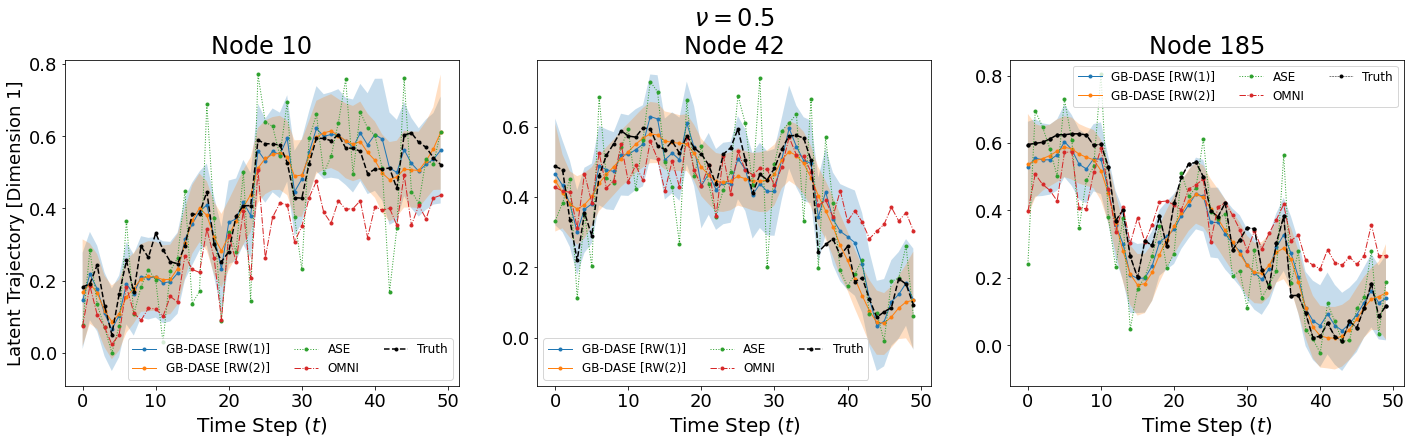

In [17]:
fig, ax = plt.subplots(figsize=(24, 6), ncols=3)

idx = 10
X_est_h_rw1 = X_est_rw1[..., idx, h]
ci = np.quantile(X_est_h_rw1, q=[0.025, 0.975], axis=0)
ax[0].plot(X_est_h_rw1.mean(axis=0), marker='.', linestyle='-', lw=1, label='GB-DASE [RW(1)]')
ax[0].fill_between(np.arange(len(Y) - k_steps), ci[0,:], ci[1, :], alpha=0.25)


X_est_h_rw2 = X_est_rw2[..., idx, h]
ci = np.quantile(X_est_h_rw2, q=[0.025, 0.975], axis=0)
ax[0].plot(X_est_h_rw2.mean(axis=0), marker='.', linestyle='-', lw=1, label='GB-DASE [RW(2)]')
ax[0].fill_between(np.arange(len(Y) - k_steps), ci[0,:], ci[1, :], alpha=0.25)

ax[0].plot(X_ase[:, idx, h], '.:', lw=1, label = 'ASE')
ax[0].plot(X_omni[:, idx, h], '.-.', lw=1, label = 'OMNI')
ax[0].plot(X[:-k_steps, idx, h], 'k.--', label = 'Truth')

ax[0].set_ylabel(r'Latent Trajectory [Dimension 1]', fontsize=18)
ax[0].set_xlabel(r'Time Step ($t$)', fontsize=20)
ax[0].legend(ncols=3, fontsize=12)
ax[0].set_title(f'Node {idx}', fontsize=24)
ax[0].tick_params(axis='both', which='major', labelsize=18)

idx = 42
X_est_h_rw1 = X_est_rw1[..., idx, h]
ci = np.quantile(X_est_h_rw1, q=[0.025, 0.975], axis=0)
ax[1].plot(X_est_h_rw1.mean(axis=0), marker='.', linestyle='-', lw=1, label='GB-DASE [RW(1)]')
ax[1].fill_between(np.arange(len(Y) - k_steps), ci[0,:], ci[1, :], alpha=0.25)

X_est_h_rw2 = X_est_rw2[..., idx, h]
ci = np.quantile(X_est_h_rw2, q=[0.025, 0.975], axis=0)
ax[1].plot(X_est_h_rw2.mean(axis=0), marker='.', linestyle='-', lw=1, label='GB-DASE [RW(2)]')
ax[1].fill_between(np.arange(len(Y) - k_steps), ci[0,:], ci[1, :], alpha=0.25)

ax[1].plot(X_ase[:, idx, h], '.:', lw=1, label='ASE')
ax[1].plot(X_omni[:, idx, h], '.-.', lw=1, label='OMNI')
ax[1].plot(X[:-k_steps, idx, h], 'k.--', label='Truth')

ax[1].set_xlabel(r'Time Step ($t$)', fontsize=20)
ax[1].legend(ncols=3, fontsize=12)
ax[1].set_title(r'$\nu = 0.5$' + f'\nNode {idx}', fontsize=24)
ax[1].tick_params(axis='both', which='major', labelsize=18)

idx = 185
X_est_h_rw1 = X_est_rw1[..., idx, h]
ci = np.quantile(X_est_h_rw1, q=[0.025, 0.975], axis=0)
ax[2].plot(X_est_h_rw1.mean(axis=0), marker='.', linestyle='-', lw=1, label='GB-DASE [RW(1)]')
ax[2].fill_between(np.arange(len(Y) - k_steps), ci[0,:], ci[1, :], alpha=0.25)

X_est_h_rw2 = X_est_rw2[..., idx, h]
ci = np.quantile(X_est_h_rw2, q=[0.025, 0.975], axis=0)
ax[2].plot(X_est_h_rw2.mean(axis=0), marker='.', linestyle='-', lw=1, label='GB-DASE [RW(2)]')
ax[2].fill_between(np.arange(len(Y) - k_steps), ci[0,:], ci[1, :], alpha=0.25)
ax[2].plot(X[:-k_steps, idx, h], 'k.--')

ax[2].plot(X_ase[:, idx, h], '.:', lw=1, label='ASE')
ax[2].plot(X_omni[:, idx, h], '.-.', lw=1, label='OMNI')
ax[2].plot(X[:-k_steps, idx, h], 'k.--', lw=0.5, label='Truth')

ax[2].set_xlabel(r'Time Step ($t$)', fontsize=20)
ax[2].legend(ncols=3, fontsize=12)
ax[2].set_title(f'Node {idx}', fontsize=24)
ax[2].tick_params(axis='both', which='major', labelsize=18)